# HistGradientBoostingClassifier — Movie Review Emotion Classification

This notebook trains and tunes only HistGradientBoostingClassifier. It does not train Decision Tree or Random Forest; it reads their saved result files only to verify split/fold parity and enable a post hoc comparison.

Run in Google Colab from the top. The setup clones the project repository, loads its existing processed CSV and movie manifests, and saves new artifacts separately under /content/hgb_outputs. Preprocessing is not rerun.

## 1. Clone the project and install the locked model library

The project's requirements-lock.txt specifies scikit-learn 1.9.0. Install before importing sklearn. The clone is read as the source of project data and protocol files.

In [1]:
from pathlib import Path
import subprocess, sys

REPO_URL = "https://github.com/it25102877/IT2011-AIML-Project.git"
REPO_DIR = Path("/content/IT2011-AIML-Project")
if not REPO_DIR.exists():
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(REPO_DIR)], check=True)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "scikit-learn==1.9.0"], check=True)
print("Project cloned to:", REPO_DIR)
print("Install complete. Continue with the imports cell.")

Project cloned to: /content/IT2011-AIML-Project
Install complete. Continue with the imports cell.


## 2. Imports, paths, and reproducibility

In [2]:
%pip install --upgrade scikit-learn==1.9.0 joblib==1.5.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 5.3 MB/s eta 0:00:00
  Attempting uninstall: joblib
    Found existing installation: joblib 1.6.0
    Uninstalling joblib-1.6.0:
      Successfully uninstalled joblib-1.6.0


In [3]:
import hashlib, json, time
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score)
from sklearn.model_selection import RandomizedSearchCV, StratifiedGroupKFold, cross_validate
from sklearn.pipeline import Pipeline

RANDOM_STATE, N_SPLITS = 42, 5
np.random.seed(RANDOM_STATE)
DATA_PATH = REPO_DIR / "results/outputs/processed_movie_reviews.csv"
TRAIN_MANIFEST = REPO_DIR / "results/outputs/train_movies.txt"
TEST_MANIFEST = REPO_DIR / "results/outputs/test_movies.txt"
PHASE2_DIR = REPO_DIR / "results/phase2"
OUTPUT_DIR = Path("/content/hgb_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("scikit-learn:", sklearn.__version__)
assert sklearn.__version__ == "1.9.0", "Restart Colab runtime and run from top if the old version remains loaded."
assert DATA_PATH.is_file() and TRAIN_MANIFEST.is_file() and TEST_MANIFEST.is_file()

scikit-learn: 1.9.0


## 3. Load and inspect the existing processed dataset

Discover the schema from the project CSV. The target is emotion; movie_name is only the grouping identifier. No title or target column is fabricated.

In [4]:
df = pd.read_csv(DATA_PATH)
TARGET, GROUP = "emotion", "movie_name"
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Dtypes:\n", df.dtypes.astype(str).to_string())
print("Missing by column:\n", df.isna().sum().sort_values(ascending=False).head(10).to_string())
assert TARGET in df and GROUP in df
assert df[TARGET].notna().all() and df[GROUP].notna().all()
class_counts = df[TARGET].value_counts().sort_index()
display(class_counts.rename("count").to_frame())
display((df[TARGET].value_counts(normalize=True).sort_index()*100).round(2).rename("percent").to_frame())
assert len(df) == 16107 and df[GROUP].nunique() == 1309 and len(class_counts) == 7

Shape: (16107, 26)
Columns: ['movie_name', 'Ratings', 'word_count', 'emotion', 'cleaned_review', 'tokens_filtered', 'genre_action', 'genre_adventure', 'genre_animation', 'genre_comedy', 'genre_crime', 'genre_documentary', 'genre_drama', 'genre_family', 'genre_fantasy', 'genre_foreign', 'genre_history', 'genre_horror', 'genre_music', 'genre_mystery', 'genre_romance', 'genre_science_fiction', 'genre_thriller', 'genre_tv_movie', 'genre_war', 'genre_western']
Dtypes:
 movie_name                object
Ratings                  float64
word_count                 int64
emotion                   object
cleaned_review            object
tokens_filtered           object
genre_action               int64
genre_adventure            int64
genre_animation            int64
genre_comedy               int64
genre_crime                int64
genre_documentary          int64
genre_drama                int64
genre_family               int64
genre_fantasy              int64
genre_foreign              int64
gen

,count
emotion,
anger,929
anticipation,2166
disgust,534
fear,1386
joy,2765
optimism,1772
sadness,6555


,percent
emotion,
anger,5.77
anticipation,13.45
disgust,3.32
fear,8.60
joy,17.17
optimism,11.00
sadness,40.70


## 4. Read the text manifests and restore the original split

Each line of train_movies.txt and test_movies.txt is a movie title. Match entries against the actual movie_name column; report and reject unmatched entries. The test split remains untouched until final evaluation.

In [5]:
def read_manifest(path):
    return [s.strip() for s in path.read_text(encoding="utf-8-sig").splitlines() if s.strip()]
train_entries, test_entries = read_manifest(TRAIN_MANIFEST), read_manifest(TEST_MANIFEST)
train_movies, test_movies = set(train_entries), set(test_entries)
known_movies = set(df[GROUP].astype(str))
unmatched_train = sorted(train_movies-known_movies)
unmatched_test = sorted(test_movies-known_movies)
print(f"Train manifest: {len(train_entries)} entries; {len(train_movies & known_movies)} matched")
print(f"Test manifest: {len(test_entries)} entries; {len(test_movies & known_movies)} matched")
print("Unmatched train:", unmatched_train)
print("Unmatched test:", unmatched_test)
assert not unmatched_train and not unmatched_test
assert train_movies.isdisjoint(test_movies)
train_df = df[df[GROUP].astype(str).isin(train_movies)].copy().reset_index(drop=True)
test_df = df[df[GROUP].astype(str).isin(test_movies)].copy().reset_index(drop=True)
assert len(train_df)==12886 and len(test_df)==3221
assert set(train_df[GROUP]).isdisjoint(set(test_df[GROUP]))
print(f"Restored split: {len(train_df):,} train rows / {len(test_df):,} test rows")
display(pd.concat([train_df[TARGET].value_counts().rename("train_count"), test_df[TARGET].value_counts().rename("test_count")], axis=1).sort_index().fillna(0).astype(int))

Train manifest: 1048 entries; 1048 matched
Test manifest: 261 entries; 261 matched
Unmatched train: []
Unmatched test: []
Restored split: 12,886 train rows / 3,221 test rows


,train_count,test_count
emotion,,
anger,744,185
anticipation,1733,433
disgust,427,107
fear,1109,277
joy,2212,553
optimism,1417,355
sadness,5244,1311


## 5. Verify split parity

Those saved JSON files are protocol references only. Their estimators are not loaded or trained. Matching movie fingerprints establish that HGB uses the same held-out movies.

In [6]:
def sha256_names(names):
    return hashlib.sha256("\n".join(sorted(set(map(str,names)))).encode("utf-8")).hexdigest()
split_hashes = {"train_movies_sha256": sha256_names(train_df[GROUP]),
                "test_movies_sha256": sha256_names(test_df[GROUP])}
reference_results = {}
for key in ["decision_tree", "random_forest"]:
    path = PHASE2_DIR / f"{key}_results.json"
    assert path.is_file(), f"Missing project reference result: {path}"
    reference_results[key] = json.loads(path.read_text(encoding="utf-8"))
    saved = reference_results[key]["split"]
    assert saved["n_train"] == len(train_df) and saved["n_test"] == len(test_df)
    for name, digest in split_hashes.items():
        assert saved[name] == digest, f"{key} has a different {name}"
    print(key, "train/test movie hashes match")
LABELS = sorted(train_df[TARGET].astype(str).unique())
assert LABELS == sorted(test_df[TARGET].astype(str).unique())
print("Classes:", LABELS)

decision_tree train/test movie hashes match
random_forest train/test movie hashes match
Classes: ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'optimism', 'sadness']


## 6. Features and fair-comparison note

The project CSV contains already-prepared tokens_filtered text, Ratings, word_count, and genre indicators. HistGradientBoostingClassifier needs dense input; the tree notebooks use sparse TF-IDF. To support HGB without refitting transformations on validation/test data, this notebook fits TF-IDF and 100-component TruncatedSVD inside each fold, then appends the existing numeric/genre columns. The source rows, target, split, folds, and metrics match the team protocol, while this feature representation differs; interpret the model comparison with that limitation in mind.

In [7]:
TEXT = "tokens_filtered"
NUMERIC = [c for c in df.columns if c in {"Ratings","word_count"} or c.startswith("genre_")]
assert TEXT in df.columns and {"Ratings","word_count"}.issubset(NUMERIC)
assert all(pd.api.types.is_numeric_dtype(df[c]) for c in NUMERIC)
X_train, y_train = train_df[[TEXT]+NUMERIC], train_df[TARGET].astype(str)
groups_train = train_df[GROUP].astype(str)
X_test, y_test = test_df[[TEXT]+NUMERIC], test_df[TARGET].astype(str)
assert not X_train.isna().any().any() and not X_test.isna().any().any()
print("Text:", TEXT, "| numeric/genre columns:", len(NUMERIC), NUMERIC)

Text: tokens_filtered | numeric/genre columns: 22 ['Ratings', 'word_count', 'genre_action', 'genre_adventure', 'genre_animation', 'genre_comedy', 'genre_crime', 'genre_documentary', 'genre_drama', 'genre_family', 'genre_fantasy', 'genre_foreign', 'genre_history', 'genre_horror', 'genre_music', 'genre_mystery', 'genre_romance', 'genre_science_fiction', 'genre_thriller', 'genre_tv_movie', 'genre_war', 'genre_western']


## 7. Fold-local dense feature pipeline

TF-IDF vocabulary and SVD components are learned only from each fold's training rows. The same pipeline is refit on the full training split after selection.

In [8]:
text_features = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=2500, ngram_range=(1,2), min_df=3, sublinear_tf=True)),
    ("svd", TruncatedSVD(n_components=100, random_state=RANDOM_STATE)),
])
preprocessor = ColumnTransformer([
    ("text", text_features, TEXT),
    ("metadata", "passthrough", NUMERIC),
], remainder="drop", sparse_threshold=0.0)
def make_model(**params):
    return Pipeline([
        ("features", preprocessor),
        ("model", HistGradientBoostingClassifier(
            random_state=RANDOM_STATE, early_stopping=False, **params))
    ])

## 8. Recreate the shared five stratified movie-group folds

CV uses training data only and groups all reviews from a movie together. Compare fold fingerprints with both teammates' saved results before fitting models.

In [9]:
cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
cv_splits = list(cv.split(X_train, y_train, groups=groups_train))
def fold_fingerprints(splits, groups):
    a = np.asarray(groups); records = []
    for i, (tr, va) in enumerate(splits, 1):
        tr_movies, va_movies = set(a[tr]), set(a[va])
        assert tr_movies.isdisjoint(va_movies), f"Movie leakage in fold {i}"
        records.append({"fold":i, "n_train":len(tr), "n_val":len(va),
                        "val_movies_sha256":sha256_names(va_movies)})
    return records
FOLDS = fold_fingerprints(cv_splits, groups_train)
for key, result in reference_results.items():
    assert FOLDS == result["cv_fingerprints"], f"Fold fingerprints differ from {key}"
    print(key, "all 5 validation movie fingerprints match")
print("Fold rows:", [(r["n_train"],r["n_val"]) for r in FOLDS])

decision_tree all 5 validation movie fingerprints match
random_forest all 5 validation movie fingerprints match
Fold rows: [(10308, 2578), (10309, 2577), (10309, 2577), (10309, 2577), (10309, 2577)]


## 9. Baseline HGB and fold-level cross-validation

Macro-F1 weights each emotion equally, useful for this imbalanced seven-class target. Accuracy and weighted F1 are also reported. Both baseline and tuned models use identical folds.

In [10]:
SCORING = {"macro_f1":"f1_macro", "accuracy":"accuracy", "weighted_f1":"f1_weighted"}
baseline_params = dict(learning_rate=0.1, max_iter=100, max_leaf_nodes=15,
                       min_samples_leaf=30, l2_regularization=1.0, class_weight="balanced")
start = time.perf_counter()
baseline_cv = cross_validate(make_model(**baseline_params), X_train, y_train,
    cv=cv_splits, scoring=SCORING, n_jobs=1, return_train_score=True)
baseline_seconds = time.perf_counter()-start
baseline = {m: np.asarray(baseline_cv["test_"+m],float) for m in SCORING}
display(pd.DataFrame({"fold":range(1,6), **{m:baseline[m] for m in SCORING}}))
print("Baseline macro-F1: %.4f ± %.4f"%(baseline["macro_f1"].mean(), baseline["macro_f1"].std()))
print("Baseline CV time: %.1f min"%(baseline_seconds/60))

,fold,macro_f1,accuracy,weighted_f1
0,1,0.159245,0.237005,0.243658
1,2,0.176761,0.251455,0.258961
2,3,0.182643,0.271634,0.282457
3,4,0.153825,0.228560,0.238176
4,5,0.170749,0.237873,0.255071


Baseline macro-F1: 0.1686 ± 0.0107
Baseline CV time: 4.1 min


## 10. Hyperparameter tuning — RandomizedSearchCV

Twelve reproducibly sampled configurations are evaluated across five shared folds (60 fits). Selection is by macro-F1. Test data is not used for tuning. The search spans learning rate, iterations, leaf count, depth, minimum leaf samples, L2 regularization, and class weights.

In [12]:
param_distributions = {
    "model__learning_rate":[0.05,0.08,0.1],
    "model__max_iter":[100,150,200],
    "model__max_leaf_nodes":[15,31],
    "model__max_depth":[None,8],
    "model__min_samples_leaf":[20,40,60],
    "model__l2_regularization":[0.0,0.5,1.0,2.0],
    "model__class_weight":[None,"balanced"],
}
N_CANDIDATES = 12
search = RandomizedSearchCV(make_model(), param_distributions=param_distributions,
    n_iter=N_CANDIDATES, scoring=SCORING, refit="macro_f1", cv=cv_splits,
    n_jobs=1, random_state=RANDOM_STATE, return_train_score=True,
    error_score="raise", verbose=1)
start = time.perf_counter()
search.fit(X_train,y_train)
tuning_seconds = time.perf_counter()-start
print(f"Completed {len(search.cv_results_['params'])} candidates / "
      f"{len(search.cv_results_['params'])*N_SPLITS} fits")
print("Best params:", search.best_params_)
print("Best CV macro-F1: %.4f"%search.best_score_)
print("Tuning time: %.1f min"%(tuning_seconds/60))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Completed 12 candidates / 60 fits
Best params: {'model__min_samples_leaf': 40, 'model__max_leaf_nodes': 15, 'model__max_iter': 200, 'model__max_depth': None, 'model__learning_rate': 0.1, 'model__l2_regularization': 0.5, 'model__class_weight': 'balanced'}
Best CV macro-F1: 0.1663
Tuning time: 49.5 min


## 11. Compare HGB configurations and save tuning results

The table includes the baseline and all tuned settings, ranked by grouped-CV macro-F1. It reports fold variation, accuracy, weighted F1, training macro-F1, and fit time.

In [13]:
res = pd.DataFrame(search.cv_results_).sort_values("rank_test_macro_f1").reset_index(drop=True)
params_cols = [c for c in res.columns if c.startswith("param_model__")]
tuning_table = res[["rank_test_macro_f1","mean_test_macro_f1","std_test_macro_f1",
    "mean_test_accuracy","mean_test_weighted_f1","mean_train_macro_f1","mean_fit_time",*params_cols]]
tuning_table.to_csv(OUTPUT_DIR/"hgb_tuning_results.csv", index=False)
display(tuning_table)
rows = [{"configuration":"Baseline HGB","cv_macro_f1_mean":baseline["macro_f1"].mean(),
         "cv_macro_f1_std":baseline["macro_f1"].std(),"cv_accuracy_mean":baseline["accuracy"].mean(),
         "cv_weighted_f1_mean":baseline["weighted_f1"].mean(),
         "mean_fit_seconds":np.mean(baseline_cv["fit_time"]),"parameters":json.dumps(baseline_params)}]
for i,r in res.iterrows():
    rows.append({"configuration":f"Tuned HGB rank {i+1}","cv_macro_f1_mean":r.mean_test_macro_f1,
        "cv_macro_f1_std":r.std_test_macro_f1,"cv_accuracy_mean":r.mean_test_accuracy,
        "cv_weighted_f1_mean":r.mean_test_weighted_f1,"mean_fit_seconds":r.mean_fit_time,
        "parameters":json.dumps(r.params,default=str,sort_keys=True)})
configuration_table = pd.DataFrame(rows)
configuration_table.to_csv(OUTPUT_DIR/"hgb_configuration_comparison.csv",index=False)
display(configuration_table.head(6))

,rank_test_macro_f1,mean_test_macro_f1,std_test_macro_f1,mean_test_accuracy,mean_test_weighted_f1,mean_train_macro_f1,mean_fit_time,param_model__min_samples_leaf,param_model__max_leaf_nodes,param_model__max_iter,param_model__max_depth,param_model__learning_rate,param_model__l2_regularization,param_model__class_weight
0,1,0.166259,0.010780,0.277667,0.272221,0.976729,55.013872,40,15,200,None,0.10,0.5,balanced
1,2,0.165470,0.014877,0.247480,0.255126,0.898005,50.819270,40,31,100,8,0.05,2.0,balanced
2,3,0.164021,0.014492,0.240261,0.251098,0.872685,44.370416,20,15,100,None,0.10,1.0,balanced
3,4,0.159567,0.011262,0.273786,0.266382,0.980944,53.712579,60,31,100,8,0.10,0.5,balanced
4,5,0.154864,0.010874,0.316158,0.281172,0.999735,69.137115,60,31,200,None,0.08,0.5,balanced
5,6,0.152828,0.007011,0.316003,0.279656,0.999735,67.533336,60,31,200,None,0.08,0.0,balanced
6,7,0.136165,0.008770,0.373352,0.282667,0.999819,45.237806,20,31,200,8,0.08,2.0,None
7,8,0.134999,0.013408,0.373740,0.282439,0.999890,35.987708,40,31,150,None,0.10,1.0,None
8,9,0.133295,0.009836,0.367687,0.278276,0.999931,34.713039,60,31,150,None,0.10,1.0,None
9,10,0.133055,0.010523,0.373197,0.280692,0.990769,26.018165,20,31,100,8,0.10,1.0,None


,configuration,cv_macro_f1_mean,cv_macro_f1_std,cv_accuracy_mean,cv_weighted_f1_mean,mean_fit_seconds,parameters
0,Baseline HGB,0.168645,0.010717,0.245306,0.255665,45.359603,"{""learning_rate"": 0.1, ""max_iter"": 100, ""max_l..."
1,Tuned HGB rank 1,0.166259,0.010780,0.277667,0.272221,55.013872,"{""model__class_weight"": ""balanced"", ""model__l2..."
2,Tuned HGB rank 2,0.165470,0.014877,0.247480,0.255126,50.819270,"{""model__class_weight"": ""balanced"", ""model__l2..."
3,Tuned HGB rank 3,0.164021,0.014492,0.240261,0.251098,44.370416,"{""model__class_weight"": ""balanced"", ""model__l2..."
4,Tuned HGB rank 4,0.159567,0.011262,0.273786,0.266382,53.712579,"{""model__class_weight"": ""balanced"", ""model__l2..."
5,Tuned HGB rank 5,0.154864,0.010874,0.316158,0.281172,69.137115,"{""model__class_weight"": ""balanced"", ""model__l2..."


## 12. Selected fold scores and final test evaluation

The highest validation macro-F1 configuration is already refit by RandomizedSearchCV on all training movies. Only now is the held-out test split scored once.

In [19]:
# Select by the same CV macro-F1 rule, including the baseline.
baseline_cv_mean = float(baseline["macro_f1"].mean())

if baseline_cv_mean >= float(search.best_score_):
    selected_name = "Baseline HGB"
    selected_params = baseline_params
    selected_cv_scores = {
        metric: baseline[metric].tolist()
        for metric in SCORING
    }

    selected_model = make_model(**baseline_params)
    refit_start = time.perf_counter()
    selected_model.fit(X_train, y_train)
    final_refit_seconds = time.perf_counter() - refit_start
else:
    selected_name = "Tuned HGB"
    selected_params = search.best_params_
    selected_model = search.best_estimator_
    selected_cv_scores = {
        metric: [
            float(search.cv_results_[f"split{i}_test_{metric}"][search.best_index_])
            for i in range(N_SPLITS)
        ]
        for metric in SCORING
    }
    final_refit_seconds = float(search.refit_time_)

cv_summary = {
    metric: {
        "folds": scores,
        "mean": float(np.mean(scores)),
        "std": float(np.std(scores, ddof=0)),
    }
    for metric, scores in selected_cv_scores.items()
}

print("Selected configuration:", selected_name)
print("Selected parameters:", selected_params)
print("Selected CV macro-F1: "
      f"{cv_summary['macro_f1']['mean']:.4f} ± "
      f"{cv_summary['macro_f1']['std']:.4f}")

# Evaluate the selected model on the held-out test set.
pred = selected_model.predict(X_test)

test_metrics = {
    "accuracy": float(accuracy_score(y_test, pred)),
    "precision_macro": float(precision_score(
        y_test, pred, labels=LABELS, average="macro", zero_division=0
    )),
    "recall_macro": float(recall_score(
        y_test, pred, labels=LABELS, average="macro", zero_division=0
    )),
    "f1_macro": float(f1_score(
        y_test, pred, labels=LABELS, average="macro", zero_division=0
    )),
    "f1_weighted": float(f1_score(
        y_test, pred, labels=LABELS, average="weighted", zero_division=0
    )),
}

report = classification_report(
    y_test, pred, labels=LABELS, output_dict=True, zero_division=0
)
display(pd.DataFrame(report).T)
print("Test metrics:", test_metrics)

Selected configuration: Baseline HGB
Selected parameters: {'learning_rate': 0.1, 'max_iter': 100, 'max_leaf_nodes': 15, 'min_samples_leaf': 30, 'l2_regularization': 1.0, 'class_weight': 'balanced'}
Selected CV macro-F1: 0.1686 ± 0.0107


,precision,recall,f1-score,support
anger,0.113360,0.151351,0.129630,185.000000
anticipation,0.177358,0.217090,0.195223,433.000000
disgust,0.027778,0.037383,0.031873,107.000000
fear,0.178363,0.220217,0.197092,277.000000
joy,0.246677,0.301989,0.271545,553.000000
optimism,0.184659,0.183099,0.183876,355.000000
sadness,0.470398,0.333333,0.390179,1311.000000
accuracy,0.265756,0.265756,0.265756,0.265756
macro avg,0.199799,0.206352,0.199917,3221.000000
weighted avg,0.300778,0.265756,0.277393,3221.000000


Test metrics: {'accuracy': 0.2657559764048432, 'precision_macro': 0.19979900685563343, 'recall_macro': 0.20635175423953564, 'f1_macro': 0.19991661450371173, 'f1_weighted': 0.27739278710230736}


## 13. Confusion matrix and saved model/results

All outputs are new Colab files, separate from the cloned project's existing models and data.

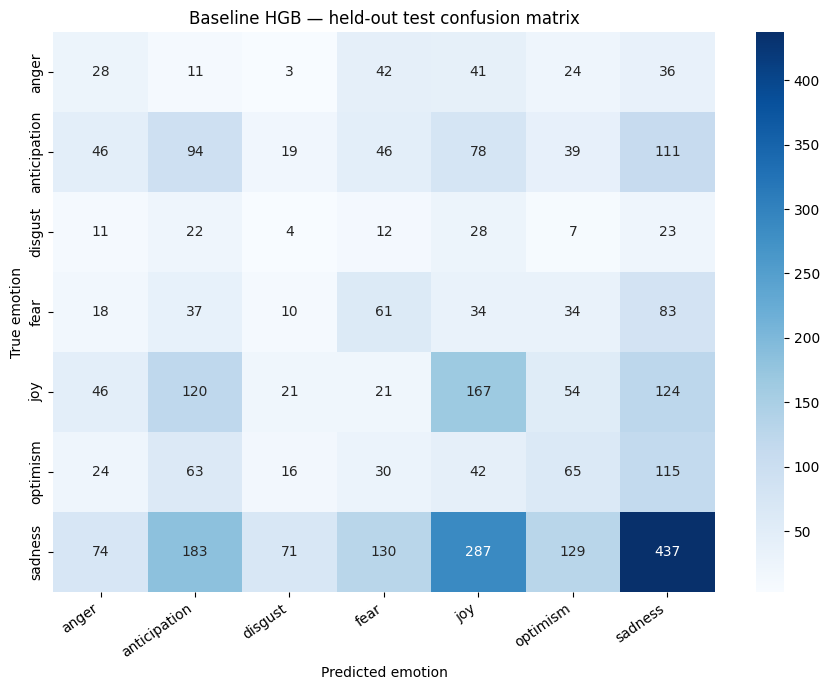

Saved selected model and matching outputs to: /content/hgb_outputs


In [24]:
# Confusion matrix for the selected model's predictions.
cm = confusion_matrix(y_test, pred, labels=LABELS)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=LABELS, yticklabels=LABELS, ax=ax
)
ax.set(
    title=f"{selected_name} — held-out test confusion matrix",
    xlabel="Predicted emotion",
    ylabel="True emotion",
)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "hgb_confusion_matrix.png", dpi=180, bbox_inches="tight")
plt.show()

# Save the same selected estimator used for the metrics above.
MODEL_PATH = OUTPUT_DIR / "hist_gradient_boosting_classifier.joblib"
joblib.dump(selected_model, MODEL_PATH)

# Save fold scores for the selected model, not the prior search winner.
fold_rows = [
    {"fold": fold_i + 1, "metric": metric, "score": score}
    for metric, scores in selected_cv_scores.items()
    for fold_i, score in enumerate(scores)
]
pd.DataFrame(fold_rows).to_csv(
    OUTPUT_DIR / "hgb_selected_cv_fold_scores.csv", index=False
)

# Save predictions and metrics from the selected model.
pd.DataFrame({
    "movie_name": test_df[GROUP].values,
    "y_true": y_test.values,
    "y_pred": pred,
}).to_csv(OUTPUT_DIR / "hgb_test_predictions.csv", index=False)

summary = {
    "model": "HistGradientBoostingClassifier",
    "selected_configuration": selected_name,
    "selected_parameters": selected_params,
    "dataset": "results/outputs/processed_movie_reviews.csv",
    "target": TARGET,
    "feature_columns": [TEXT] + NUMERIC,
    "feature_note": (
        "Existing tokens_filtered text with fold-local TF-IDF and SVD "
        "(100 components), plus existing numeric and genre features. "
        "SVD is used because HGB requires dense inputs."
    ),
    "split": {
        "train_rows": len(train_df),
        "test_rows": len(test_df),
        **split_hashes,
    },
    "cv": {
        "method": "StratifiedGroupKFold",
        "n_splits": N_SPLITS,
        "fold_fingerprints": FOLDS,
        "selected": cv_summary,
    },
    "tuning": {
        "method": "RandomizedSearchCV",
        "candidates": len(search.cv_results_["params"]),
        "fits": len(search.cv_results_["params"]) * N_SPLITS,
        "selection_metric": "macro_f1",
        "best_tuned_parameters": search.best_params_,
        "best_tuned_cv_macro_f1": float(search.best_score_),
        "elapsed_seconds": float(tuning_seconds),
    },
    "baseline": {
        "parameters": baseline_params,
        "cv_scores": {
            metric: scores.astype(float).tolist()
            for metric, scores in baseline.items()
        },
        "elapsed_seconds": float(baseline_seconds),
    },
    "final_refit_seconds": float(final_refit_seconds),
    "test_metrics": test_metrics,
    "classification_report": report,
}

(OUTPUT_DIR / "hgb_experiment_summary.json").write_text(
    json.dumps(summary, indent=2), encoding="utf-8"
)

print("Saved selected model and matching outputs to:", OUTPUT_DIR)

# Standardized Phase 2 team evaluation artifacts (src.evaluation format)
try:
    if str(REPO_DIR) not in sys.path:
        sys.path.insert(0, str(REPO_DIR))
    from src.evaluation import save_model_results

    # Use reference results (already loaded and verified in Cell 11) for split invariants and baselines
    ref_rf = reference_results["random_forest"]

    # Match review IDs with project reference predictions
    ref_pred_df = pd.read_csv(PHASE2_DIR / "random_forest_test_predictions.csv")
    test_rids = ref_pred_df["review_id"].tolist()

    pred_standard_df = pd.DataFrame({
        "row_id": list(range(len(test_df))),
        "review_id": test_rids,
        "movie_name": test_df[GROUP].values,
        "y_true": y_test.values,
        "y_pred": pred,
    })

    meta_hgb = {
        "model_label": "HistGradientBoosting",
        "member_id": "IT25103066",
        "algorithm": "HistGradientBoostingClassifier",
        "preprocessing": "TF-IDF (2500) + TruncatedSVD (100) + Numeric & Genres (22)",
        "tuning": {
            "method": "RandomizedSearchCV",
            "n_configs": int(len(search.cv_results_["params"])),
            "n_folds": int(N_SPLITS),
            "scoring": list(SCORING),
            "elapsed_seconds": float(tuning_seconds),
            "best_params": selected_params,
        },
    }

    test_metrics_standard = {
        "accuracy": float(test_metrics["accuracy"]),
        "macro_f1": float(test_metrics["f1_macro"]),
        "weighted_f1": float(test_metrics["f1_weighted"]),
        "per_class": {
            lbl: {
                "precision": float(report[lbl]["precision"]),
                "recall": float(report[lbl]["recall"]),
                "f1": float(report[lbl]["f1-score"]),
                "support": int(report[lbl]["support"]),
            }
            for lbl in LABELS
        },
        "confusion_matrix": cm.tolist(),
    }

    cv_standard = {
        "n_splits": int(N_SPLITS),
        "macro_f1": cv_summary["macro_f1"],
        "accuracy": cv_summary["accuracy"],
        "weighted_f1": cv_summary["weighted_f1"],
    }

    for target_dir in [OUTPUT_DIR, PHASE2_DIR]:
        if target_dir.exists():
            save_model_results(
                out_dir=target_dir,
                model_key="hist_gradient_boosting",
                meta=meta_hgb,
                split=ref_rf["split"],
                cv=cv_standard,
                cv_fingerprints=ref_rf["cv_fingerprints"],
                test=test_metrics_standard,
                baselines=ref_rf["baselines"],
                predictions_df=pred_standard_df,
            )
    print("Standardized Phase 2 artifacts successfully saved.")
except Exception as e:
    print(f"Notice: Standardized Phase 2 export skipped: {e}")

## 15. Final summary and requirements checklist

Model selection is based on grouped validation macro-F1, never the test score. HGB training/tuning here is independent of the Decision Tree and Random Forest training.

In [25]:
print("Selected configuration:", selected_name)
print("Parameters:", selected_params)
print(
    f"CV macro-F1: {cv_summary['macro_f1']['mean']:.4f} "
    f"± {cv_summary['macro_f1']['std']:.4f}"
)
print("Test metrics:", test_metrics)

# Read saved Decision Tree and Random Forest results for comparison only.
comparison_rows = []

for model_key, result in reference_results.items():
    comparison_rows.append({
        "model": result["meta"]["model_label"],
        "cv_macro_f1_mean": result["cv"]["macro_f1"]["mean"],
        "cv_macro_f1_std": result["cv"]["macro_f1"]["std"],
        "test_accuracy": result["test"]["accuracy"],
        "test_macro_f1": result["test"]["macro_f1"],
        "test_weighted_f1": result["test"]["weighted_f1"],
    })

comparison_rows.append({
    "model": f"HistGradientBoostingClassifier ({selected_name})",
    "cv_macro_f1_mean": cv_summary["macro_f1"]["mean"],
    "cv_macro_f1_std": cv_summary["macro_f1"]["std"],
    "test_accuracy": test_metrics["accuracy"],
    "test_macro_f1": test_metrics["f1_macro"],
    "test_weighted_f1": test_metrics["f1_weighted"],
})

posthoc_comparison = pd.DataFrame(comparison_rows)
display(posthoc_comparison)
posthoc_comparison.to_csv(
    OUTPUT_DIR / "hgb_posthoc_project_model_comparison.csv",
    index=False,
)

checklist = pd.DataFrame([
    ("Model selection", "Baseline and tuned HGB compared by grouped-CV macro-F1."),
    ("Test evaluation", "Selected model evaluated on the held-out test split."),
    ("Saved files", "Selected model and matching predictions, metrics, folds, and confusion matrix."),
    ("Comparison", "DT/RF results read from saved files; those models are not trained here."),
], columns=["Requirement", "How satisfied"])
display(checklist)

Selected configuration: Baseline HGB
Parameters: {'learning_rate': 0.1, 'max_iter': 100, 'max_leaf_nodes': 15, 'min_samples_leaf': 30, 'l2_regularization': 1.0, 'class_weight': 'balanced'}
CV macro-F1: 0.1686 ± 0.0107
Test metrics: {'accuracy': 0.2657559764048432, 'precision_macro': 0.19979900685563343, 'recall_macro': 0.20635175423953564, 'f1_macro': 0.19991661450371173, 'f1_weighted': 0.27739278710230736}


,model,cv_macro_f1_mean,cv_macro_f1_std,test_accuracy,test_macro_f1,test_weighted_f1
0,Decision Tree,0.176674,0.021074,0.286557,0.191386,0.278800
1,Random Forest,0.170778,0.013758,0.272897,0.194211,0.270704
2,HistGradientBoostingClassifier (Baseline HGB),0.168645,0.010717,0.265756,0.199917,0.277393


,Requirement,How satisfied
0,Model selection,Baseline and tuned HGB compared by grouped-CV ...
1,Test evaluation,Selected model evaluated on the held-out test ...
2,Saved files,"Selected model and matching predictions, metri..."
3,Comparison,DT/RF results read from saved files; those mod...


In [26]:
reloaded_model = joblib.load(MODEL_PATH)
sample_X = X_test.iloc[:5]
saved_predictions = reloaded_model.predict(sample_X)
expected_predictions = selected_model.predict(sample_X)

assert len(saved_predictions) == min(5, len(X_test))
assert np.array_equal(saved_predictions, expected_predictions)

print("Model reload and prediction check passed.")
print("Saved model:", MODEL_PATH)

Model reload and prediction check passed.
Saved model: /content/hgb_outputs/hist_gradient_boosting_classifier.joblib
